# **Detección de fraude con tarjetas de crédito**

Para empezar comencemos con un resumen de la documentación del dataset. Este dataset contiene 284,807 transacciones con tarjeta de crédito realizadas por clientes europeos en septiembre de 2013. Incluye 492 casos de fraude (0.172%), lo que lo convierte en un problema altamente desbalanceado. Las variables V1–V28 provienen de una transformación PCA para proteger la privacidad de los usuarios, mientras que Time, Amount y Class permanecen sin transformar. Nuestro objetivo principal es desarrollar modelos capaces de detectar transacciones fraudulentas.

In [3]:
#Importamos las librerías necesarias
import pandas as pd
import kagglehub
import os
from imblearn.over_sampling import SMOTE
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import imblearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler


In [4]:
#Cargamos el dataset

# df = pd.read_csv("creditcard.csv")
#path = "C:/path/to/csv/folder"
#df = pd.read_csv(os.path.join(path, "creditcard.csv"))

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print(path)
df=pd.read_csv(os.path.join(path,"creditcard.csv"))
df.head()


C:\Users\angel\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Análisis Exploratorio de Datos

Iniciemos con una exploración de los datos 

In [5]:
df.shape

(284807, 31)

* 284,807 filas (cada fila es una transacción).

* 31 columnas, que equivalen a 30 variables numéricas y la variable objetivo ```Class```

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [7]:
#Vamos a confirmar que no hay valores nulos en el dataset
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [9]:
#Observamos que la variable "Class" es una variable categórica que indica si la transacción es fraudulenta (1) o no (0)
#Cambiamos el tipo de dato de la variable "Class" a categórico
df['Class'] = df['Class'].astype('category')

Ahora revisamos la distribución de la variable objetivo ```Class```

In [10]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Este resultado nos muestra lo siguiente:

* 0 → ~0.99827 (99.827% transacciones normales)

* 1 → ~0.00172 (0.172% fraudes)

Por lo que nuestro dataset esta desbalanceado

C:\Users\angel\AppData\Local\Temp\ipykernel_16356\2328576663.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Class', palette=colors)


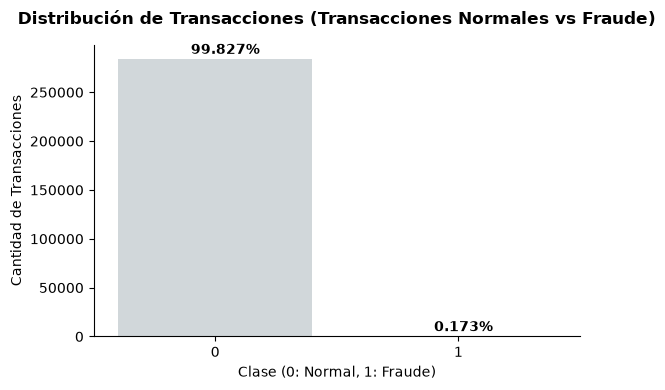

In [11]:
plt.figure(figsize=(6, 4))
# Usamos colores ejecutivos: Gris para normal, Azul oscuro para fraude
colors = ["#CFD8DC", "#1E88E5"] 

ax = sns.countplot(data=df, x='Class', palette=colors)
plt.title("Distribución de Transacciones (Transacciones Normales vs Fraude)", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Clase (0: Normal, 1: Fraude)", fontsize=10)
plt.ylabel("Cantidad de Transacciones", fontsize=10)

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.3f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 5000
    ax.annotate(percentage, (x, y), fontsize=10, fontweight='bold')

sns.despine() # Quita los bordes innecesarios
plt.tight_layout()
plt.show()

Veamos la distribución de ```Amount```

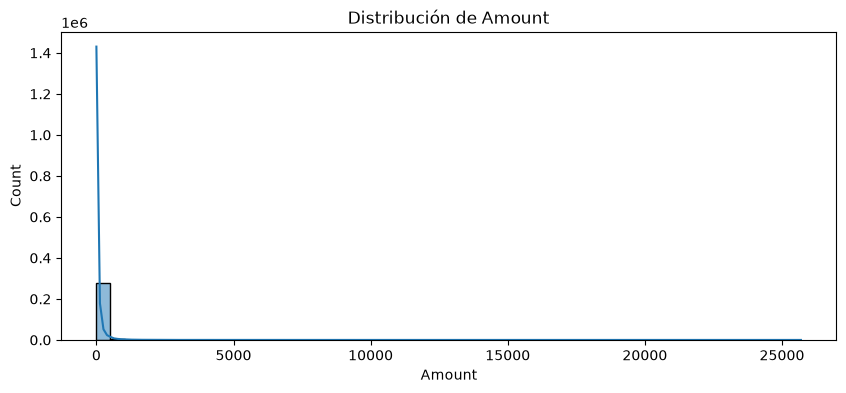

In [12]:
plt.figure(figsize=(10,4))
sns.histplot(data=df, x='Amount', bins=50, kde=True)
plt.title("Distribución de Amount")
plt.show()


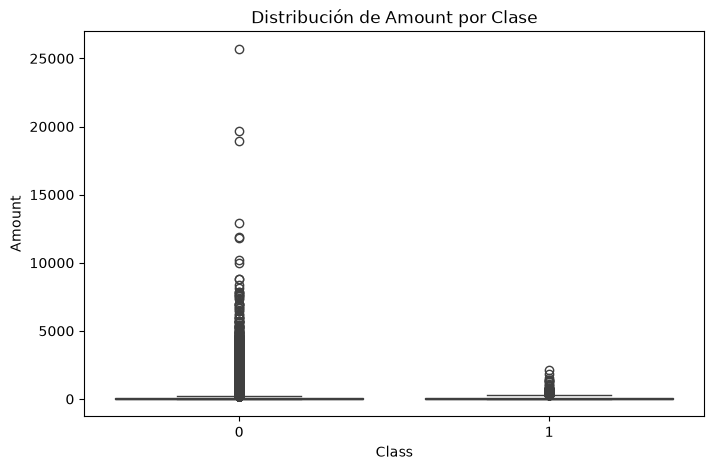

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Class', y='Amount')
plt.title("Distribución de Amount por Clase")
plt.show()


In [14]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


C:\Users\angel\AppData\Local\Temp\ipykernel_16356\303263750.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y='Amount', palette=["#CFD8DC", "#1E88E5"], showfliers=False)


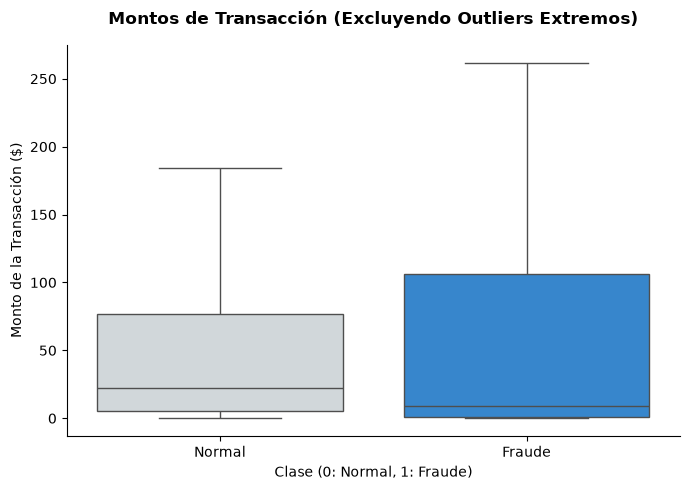

In [15]:
plt.figure(figsize=(7, 5))

#Acotamos el eje Y hasta $500 para poder apreciar las cajas del boxplot
sns.boxplot(data=df, x='Class', y='Amount', palette=["#CFD8DC", "#1E88E5"], showfliers=False)

plt.title("Montos de Transacción (Excluyendo Outliers Extremos)", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Clase (0: Normal, 1: Fraude)", fontsize=10)
plt.ylabel("Monto de la Transacción ($)", fontsize=10)
plt.xticks([0, 1], ['Normal', 'Fraude'])

sns.despine()
plt.tight_layout()
plt.show()

Se pude observar que los montos que fueron detectados como fraude son más altos que los no se detectaron con fraude, sin embargo, observando la mediana, la mayoría de los montos son pequeños, incluso el máximo de montos es menor que las transacciones normales.

Con el gráfico de *Distribución de Amount por Clase* se puede ver más a detalle que las transacciones normales ```Class = 0```, hay muchos outliers, pero esto puede significar que hay montos legítimos desde muy pequeños hasta muy grandes, es decir, que muchas de las compras grandes son verdaderas y otro punto a destacar es que en el caso de los fraudes ```Class= 1``` rara vez son montos grandes, indicando que se hacen cargos pequeños para evitar sospechas.

Análisis de la variable ```Time```

 Según la documentación, la variable 'Tiempo' contiene los segundos transcurridos entre cada transacción y la primera transacción en el conjunto de datos. Recordemos que es un data set de 2 días.

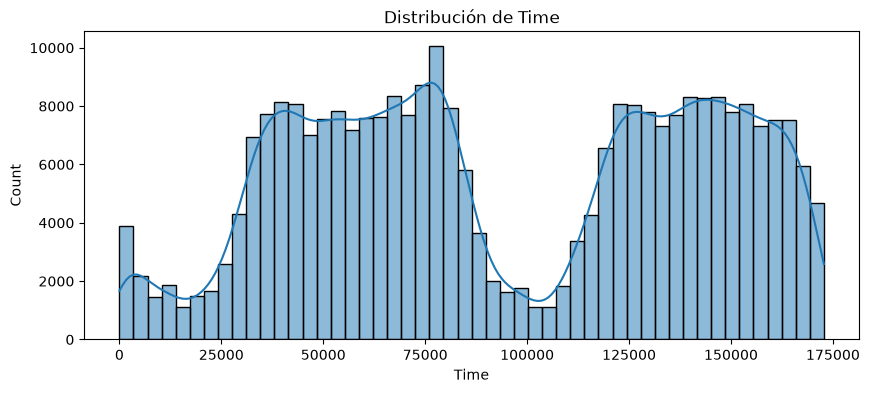

In [16]:
plt.figure(figsize=(10,4))
sns.histplot(df['Time'], bins=50, kde=True)
plt.title("Distribución de Time")
plt.show()


Aunque la variable time es un contador acumulado, hay dos picos muy marcos, el que esta aproximadamente cerca de los 75,000 segundos y el que esta aproximadamente cerca de los 140,000 segundos, convirtamos estos segundos a horas, para facilitar la interpretación de los datos.

In [17]:
df['Hour'] = df['Time'] / 3600

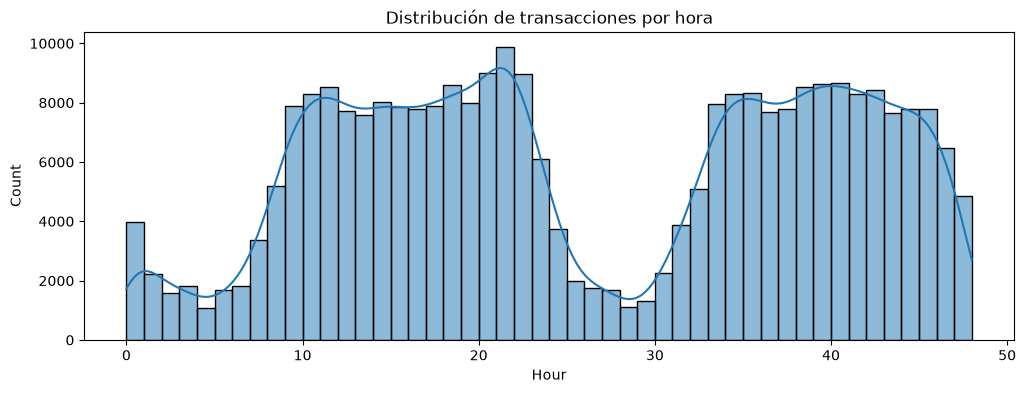

In [18]:
plt.figure(figsize=(12,4))
sns.histplot(df['Hour'], bins=48, kde=True)
plt.title("Distribución de transacciones por hora")
plt.show()

Ahora es más fácil ver que los picos están al rededor de las 20 horas y las 40 horas, y además hay una caída fuerte después de las 24 horas y las siguientes 10 horas, es decir, después de la media noche hasta casi las 10 a.m..

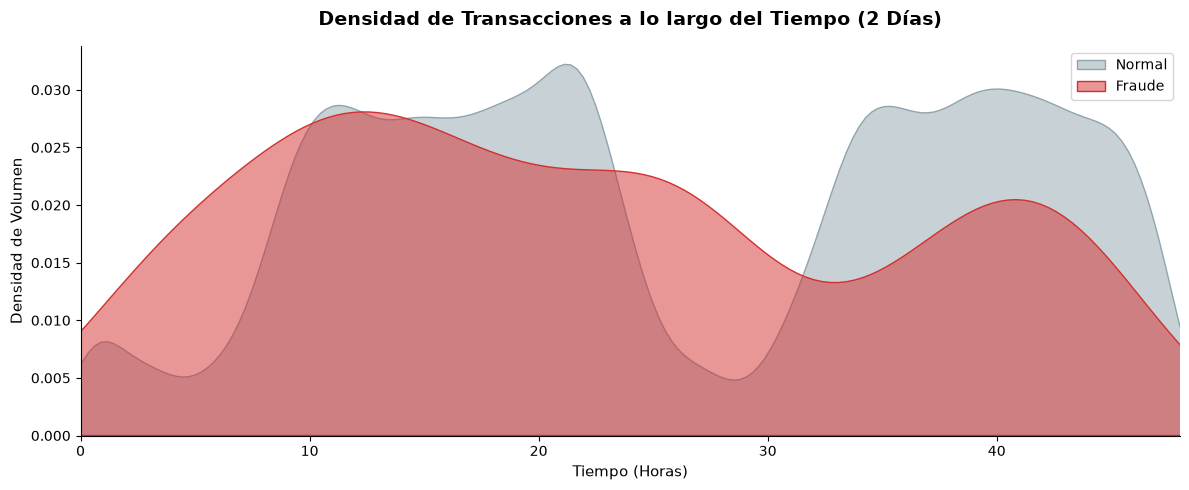

In [19]:
plt.figure(figsize=(12, 5))

#Densidad para transacciones normales vs fraude
sns.kdeplot(data=df[df['Class'] == 0], x='Hour', label='Normal', color='#90A4AE', fill=True, alpha=0.5)
sns.kdeplot(data=df[df['Class'] == 1], x='Hour', label='Fraude', color='#D32F2F', fill=True, alpha=0.5)

plt.title("Densidad de Transacciones a lo largo del Tiempo (2 Días)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Tiempo (Horas)", fontsize=11)
plt.ylabel("Densidad de Volumen", fontsize=11)
plt.xlim(0, 48) #Limitar a las 48 horas de los dos días
plt.legend(loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

En la anterior gráfica es más fácil ver que transacciones fraude son las que actúan en los periodos de tiempo donde las transacciones normales se apagan.

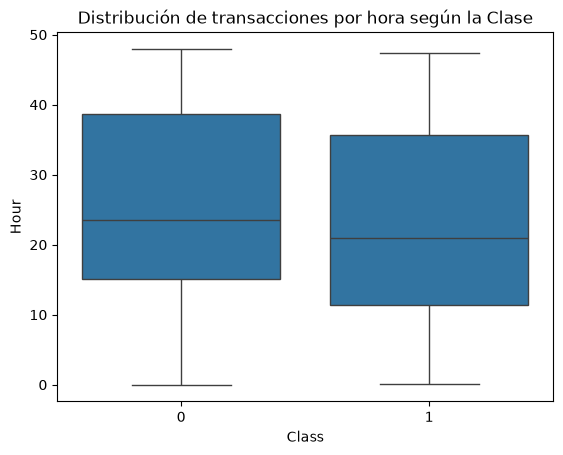

In [20]:
sns.boxplot(data=df, x='Class', y='Hour')
plt.title("Distribución de transacciones por hora según la Clase")
plt.show()

Se observa visualmente cómo las transacciones legítimas/normales disminuyen drásticamente durante las horas de la madrugada (entre las horas 10 a 18 y 34 a 42), mientras que las transacciones fraudulentas no muestran una caída tan pronunciada, manteniendo actividad constante.

### Analicemos las correlaciones entre las variables

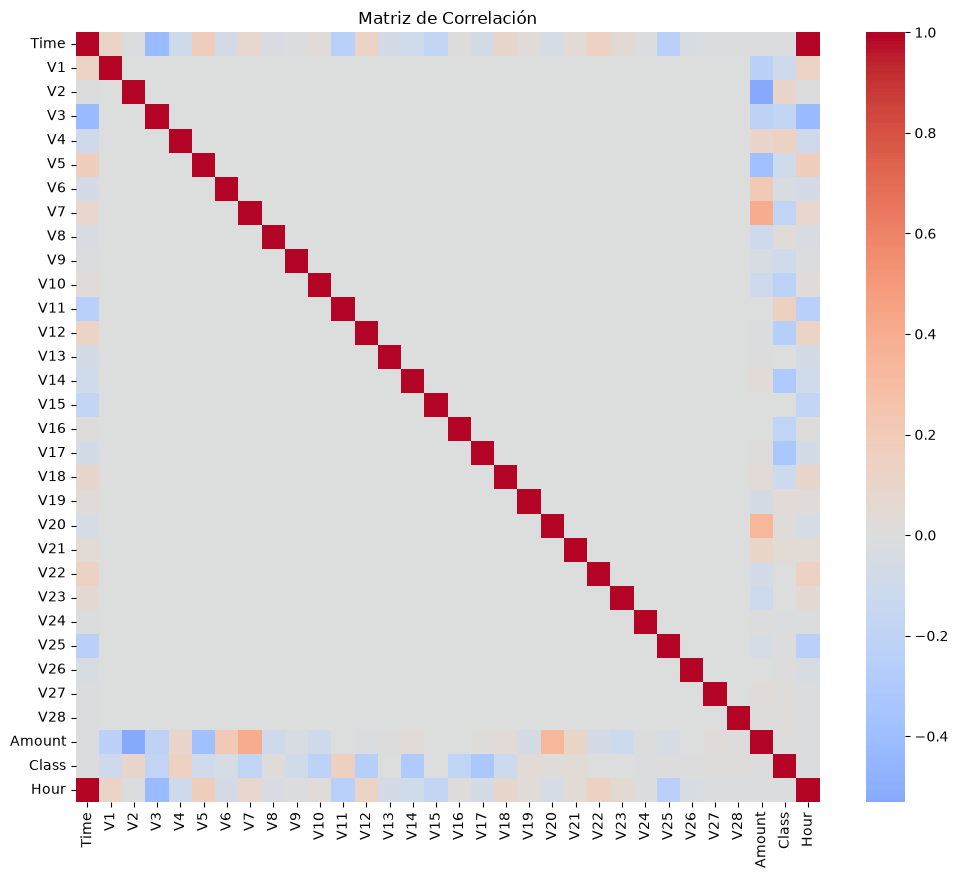

In [21]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Matriz de Correlación")
plt.show()


Observemos que no hay fuertes correlaciones entre sí, por lo que ellos fraudes no se explican por sí solos con el monto y el tiempo.

Distribución de los ```features```

Recordemos que las variables V1, V2, … V28 son los componentes principales obtenidos con PCA, están escaladas, tienen media 0 y varianza 1.

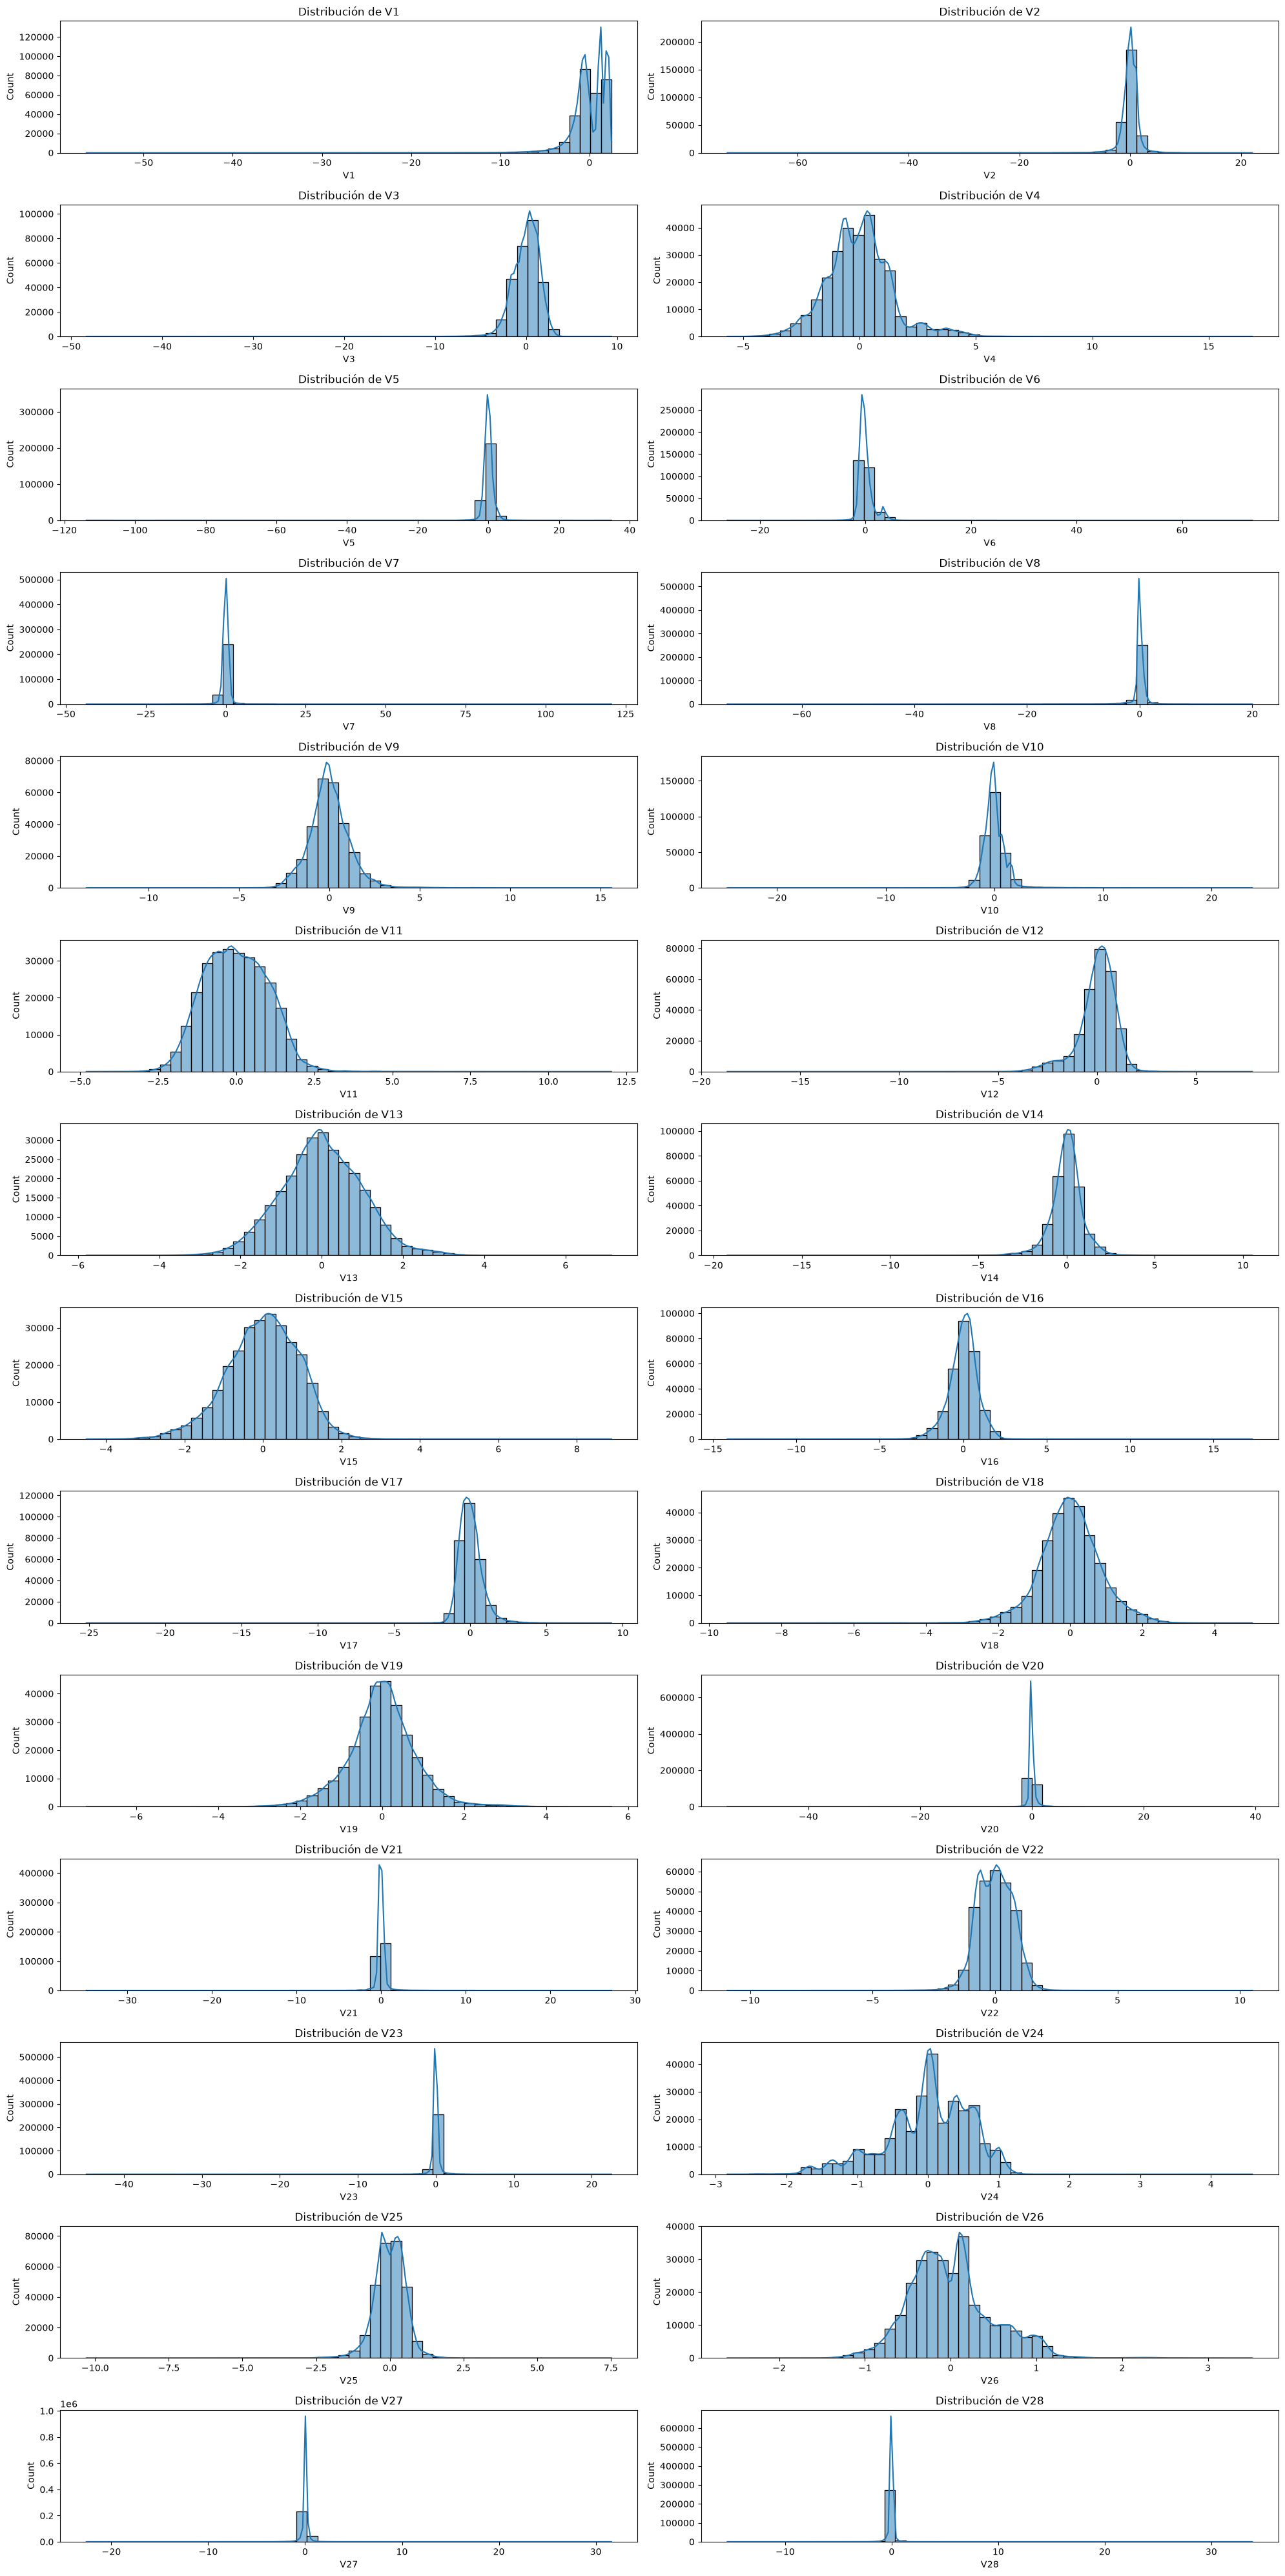

In [22]:
features = [f"V{i}" for i in range(1, 29)]

plt.figure(figsize=(20, 40))

for i, col in enumerate(features, 1):
    plt.subplot(14, 2, i)
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribución de {col}")

plt.tight_layout()
plt.show()


Muchas variables presentan forma de campana centrada en 0. Algunas componentes muestran valores extremos poco frecuentes, lo que podría indicar presencia de outliers o comportamientos atípicos. Analicemos algunas variables que presentaron estás característica de valores extremos, como:
* V10
* V12
* V14
* V17

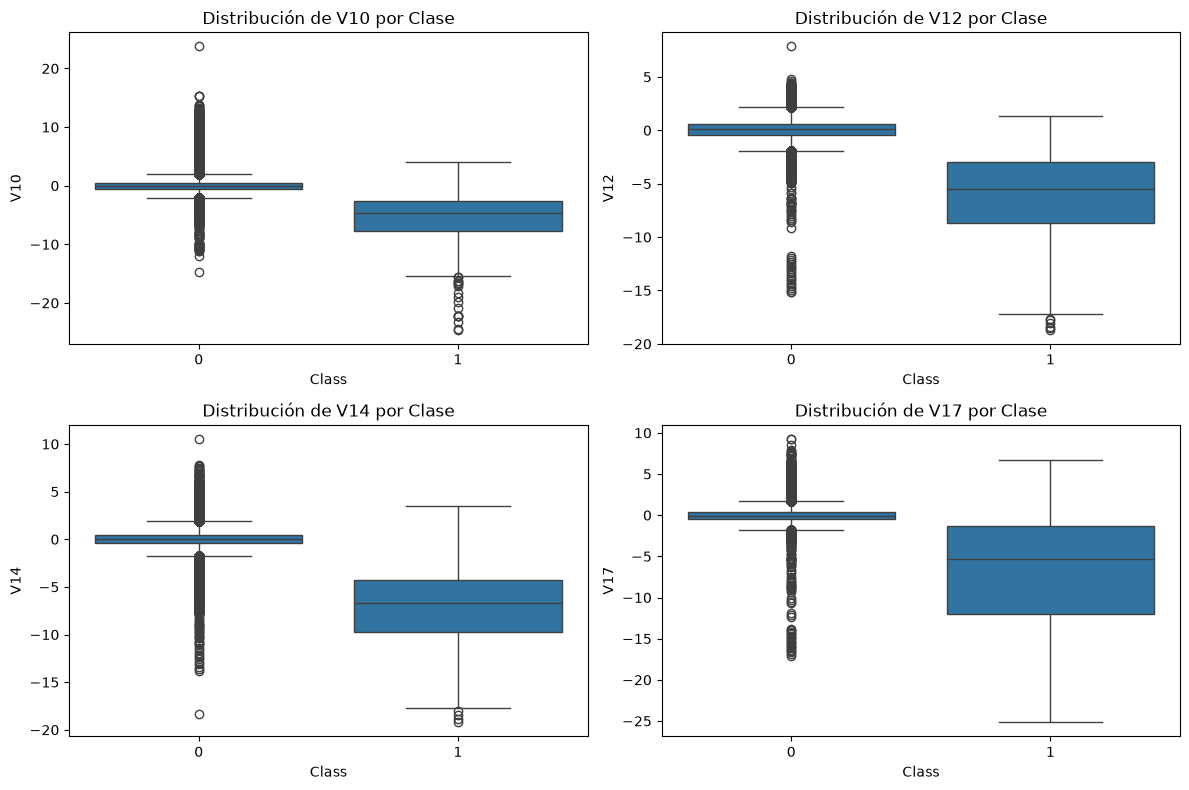

In [23]:
features = ['V10', 'V12', 'V14', 'V17']

plt.figure(figsize=(12, 8))

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x='Class', y=col)
    plt.title(f"Distribución de {col} por Clase")

plt.tight_layout()
plt.show()


Las variables V10, V12, V14 y V17 muestran diferencias significativas entre transacciones normales y fraudulentas. En particular, V10, V12 y V14 presentan valores considerablemente más negativos en la clase fraudulenta, mientras que V17 muestra valores más altos para esta misma clase. Por lo tanto, estas variables son altamente relevantes para los futuros modelos.

## Preprocesamiento de los datos

Hemos visto que las variables V1 a V28 ya vienen escaladas, no tenemos valores nulos y nuestra variable objetivo ya se convirtió a categórica, y también ya tenemos una nueva varible de Horas para facilitar su interpretación, sin embargo, nuestros modelos dependen de la escala, por lo que debemos de estandarizarlos.

In [24]:
#Separamos las variables independientes de la variable objetivo
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Class'])
y = df['Class']

#Separamos el dataset en entrenamiento y prueba, manteniendo la proporción de clases
#Separar el set de Prueba (Test) final (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Del 80% restante, separar Entrenamiento (60%) y Validación (20%)
# El test_size=0.25 sobre el 80% restante da exactamente el 20% del total general.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

In [25]:
#Escalamos la variable "Amount" y "Time" utilizando RobustScaler

scaler = RobustScaler()

X_train[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_test[['Amount', 'Time']] = scaler.transform(X_test[['Amount', 'Time']])
X_val[['Amount', 'Time']] = scaler.transform(X_val[['Amount', 'Time']])

print(f"Entrenamiento: {X_train.shape} (Fraudes: {y_train.astype(int).sum()})")
print(f"Validación:    {X_val.shape} (Fraudes: {y_val.astype(int).sum()})")
print(f"Prueba:        {X_test.shape} (Fraudes: {y_test.astype(int).sum()})")


Entrenamiento: (170883, 31) (Fraudes: 295)
Validación:    (56962, 31) (Fraudes: 99)
Prueba:        (56962, 31) (Fraudes: 98)


Hacemos un balanceo de los datos

In [26]:

#SMOTE al conjunto de entrenamiento ajustado
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Estructura del set de entrenamiento tras SMOTE: {X_train_res.shape}")
print(f"Distribución de clases en entrenamiento: \n{y_train_res.value_counts()}")


Estructura del set de entrenamiento tras SMOTE: (341176, 31)
Distribución de clases en entrenamiento: 
Class
0    170588
1    170588
Name: count, dtype: int64


In [27]:
#Verificamos que el balanceo se haya realizado correctamente
print(pd.Series(y_train).value_counts())
print(pd.Series(y_train_res).value_counts())


Class
0    170588
1       295
Name: count, dtype: int64
Class
0    170588
1    170588
Name: count, dtype: int64


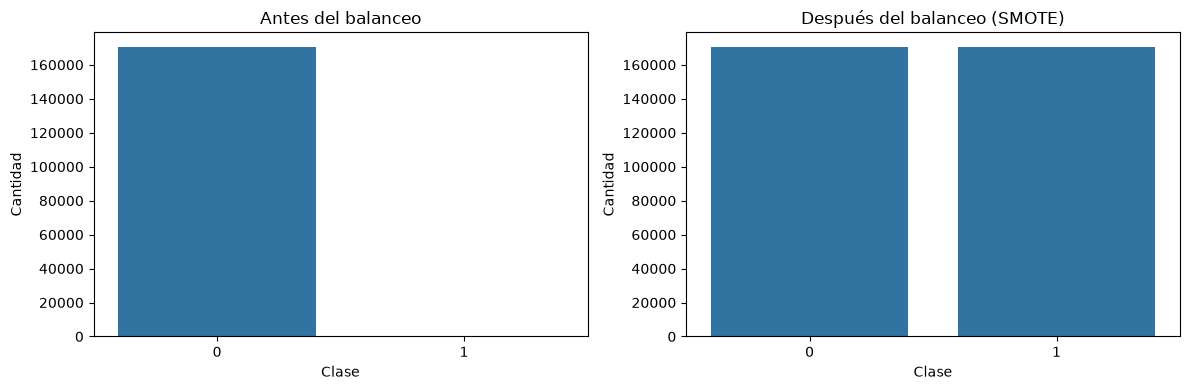

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Antes del balanceo")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Cantidad")

sns.countplot(x=y_train_res, ax=axes[1])
axes[1].set_title("Después del balanceo (SMOTE)")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()


A modo de resumen para esta primera parte del EDA y Preprocesamiento de los datos, Amount y Hour ahora aportan información crítica sobre el monto y el momento de la transacción, y su escalamiento evita que dominen el modelo, la variable objetivo Class ya esta separada y solo el conjunto de entrenamiento fue balanceado mediante SMOTE para evitar sesgos y mejorar la capacidad de detección de la clase minoritaria.


Finalmente reservamos las bases para los futuros modelos.

In [29]:

folder = "artifacts" 
if not os.path.exists(folder):
    os.makedirs(folder)
#Exportar los conjuntos de características (X) a la carpeta artifacts
X_train_res.to_csv(os.path.join(folder, "X_train.csv"), index=False)
X_val.to_csv(os.path.join(folder, "X_val.csv"), index=False)
X_test.to_csv(os.path.join(folder, "X_test.csv"), index=False)
X_train.to_csv(os.path.join(folder, "X_train_no_res.csv"), index=False)

#Exportar las variables objetivo (y) a la carpeta artifacts
y_train_res.astype(int).to_csv(os.path.join(folder, "y_train.csv"), index=False)
y_val.astype(int).to_csv(os.path.join(folder, "y_val.csv"), index=False)
y_test.astype(int).to_csv(os.path.join(folder, "y_test.csv"), index=False)
y_train.astype(int).to_csv(os.path.join(folder, "y_train_no_res.csv"), index=False)

print(f"Se han exportado los datos a '{folder}/'")

Se han exportado los datos a 'artifacts/'
